# **Esame del 26 giugno 2025**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Si vuole approssimare numericamente il seguente integrale definito
$$
I = \int_{-\pi}^\pi \sin(x)x^3 dx
$$

#### **(1a) (3 punti) [T]**  
Introdurre i metodi di integrazione del punto medio e di Simpson, nella versione non composita e composita, illustrando le loro proprietà (esattezza e accuratezza).


In [3]:
#il metodo del punto medio prevede di approssimare l'integrale con la seguente formula: 
#Ipm=(b-a)*f(m) dove m =b+a/2
#il punto medio composito invece prevede di suddividere l'intervallo [a, b] in n sottointervalli di ampiezza H. In questo modo la formula del metodo
#del punto medio composito diventa: Ipmc=H*somma(i=1 a N) di (f(xi)+f(xi+1))/2
#l'errore del metodo del punto medio è dato da una costante per H^2*max|f''(x)| quindi il grado di esattezza del metodo è1, mentre il suo ordine di accuratezza è 2

#il metodo di Simpson invece prevede di approssimare la funzione con una parabola, quindi la formula dell'integrale approssimato diventa:
#Is=(b-a)/6*[f(a)+4f(m)+f(b)]
#considerando la formula composita avremo:
#Isc= H/6*somma(i=1 a N ) di [f(xi-1)+4f((xi-1+xi)/2)+f(xi)]
#l'errore del metodo di Simpson è minore di una costante per H^4 per il max|f'v(x)| quindi l'ordine di accuratezza è 4, mentre il grado di esattezza è 3.


##### **Soluzione.**

Una prima possibilità è utilizzare la formula del punto medio, in cui l'integrale viene approssimato da
$$
    I \approx I_{pm} = (b-a) f\left(m\right)
$$
dove $m$ denota il punto medio dell'intervallo di integrazione $[a, b]$, dato da
$m = 0.5(a+b)$. Un'ulteriore opzione che si può considerare è data dalla formula di Simpson,
in cui approssimiamo $I$ utilizzando il valore della funzione in tre punti, come
$$
    I \approx I_s = \frac{b-a}{6} \left[ f(a) + 4 f\left( m \right) +
        f(b) \right],
$$
dove $m = 0.5 (a+b)$. Tale formula corrisponde all'integrale di una parabola passante per i
punti
$$
    (a, f(a)), \quad \left(m, f\left(m\right)\right),
    \quad (b, f(b))
$$
Otteniamo che l'errore
per la formula del punto medio è dato da
\begin{gather*}
    |{E_{pm}}|\leq \frac{(b-a)^3}{24}  \max_{x \in I} |{f^{\prime\prime}(x)}|,
\end{gather*}
mentre per Simpson otteniamo
$$
    |E_s| \leq \frac{(b-a)^5}{16\cdot 180} \max_{x \in I} |f^{(iv)}(x)|.
$$
Nell'integrazione composita suddividiamo l'intervallo $[a,b]$ in $n$ sotto-intervalli, dove, per $i=1,\ldots,n$, ogni intervallo è dato da $I_i = [x_{i-1}, x_i]$ con $x_i= a+ iH$ e dove $H=(b-a)/n$. Otteniamo così la formula del punto medio composito in cui il valore
dell'integrale è calcolato come
$$
    I_{pm}^c = H \sum_{i=1}^n f\left(\frac{x_{i-1} + x_i}{2}\right).
$$
Infine la formula di Simpson composita risulta data da
$$
    I_s^c = \frac{H}{6} \sum_{i=1}^n \left[ f(x_{i-1}) + 4 f\left( \frac{x_{i-1}
            + x_i}{2}\right) + f(x_i)\right].
$$
L'errore del punto medio composito è dato da $$|{E_{pm}^c}| \leq c H^2.$$
Possiamo quindi affermare che la formula del punto medio composita ha ordine di accuratezza 2,
e grado di esattezza 1 in quando integra
esattamente funzioni lineari, con derivata seconda nulla. Per la regola di quadratura di Simpson composito è possibile derivare un limite superiore per l'errore
commesso che è dato da
$$
    |{E_s^c}| \leq \frac{b-a}{16\cdot 180} \max_{x\in[a,b]} |{f^{(iv)}(x)}|
    H^4 = c H^4 \quad \text{dove} \quad
    c = \frac{b-a}{16\cdot 180} \max_{x\in[a,b]} |{f^{(iv)}(x)}|,
$$
l'ordine di accuratezza è quindi pari a 4, nel caso in cui la funzione $f \in C^4(a, b)$, e il grado di esattezza è in questo caso $3$.



#### **(1b) (3 punti) [P]**  
Data la soluzione esatta $I = -12\pi + 2\pi^3$, calcolare l'errore commesso dai due metodi compositi per una suddivisione di $N = [10, 20, 40, 80, 160]$ sotto-intervalli utilizzando le function fornite. Riportare graficamente l'errore ottenuto e confrontarlo con il decadimento dell'errore predetto dalla teoria commentando il risultato ottenuto.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from utilis_integration import *

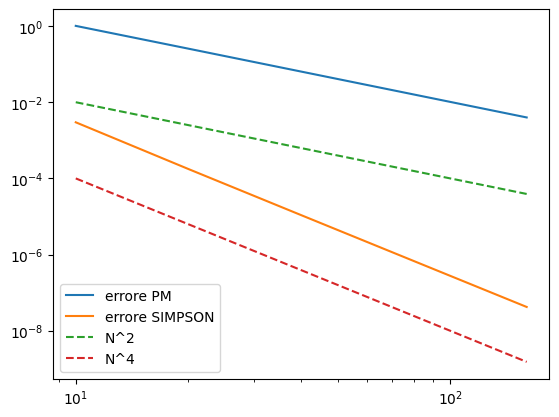

In [9]:
f=lambda x: np.sin(x)* x**3
a=-np.pi
b=np.pi

I_ex= -12*np.pi+2*np.pi**3

N=np.array([10,20,40,80,160])
err_pm=[]
err_simp=[]

for n in N:
    I_pm=pmedcomp(f, a, b, n)
    err_pm.append(np.abs(I_pm-I_ex))

    I_simp=simpcomp(f,a,b,n)
    err_simp.append(np.abs(I_simp-I_ex))

plt.figure()
plt.loglog(N, err_pm, label='errore PM')
plt.loglog(N, err_simp, label='errore SIMPSON')
plt.loglog(N, 1/N**2, '--', label='N^2')
plt.loglog(N, 1/N**4, '--', label='N^4')
plt.legend()
plt.show()

In [10]:
#rappresentando l'errore in scala logaritmica e rappresentando anche gli ordini di accuratezza corrispondenti, vediamo che l'errore decresce
#come ci aspettavamo dalla teoria

##### **Soluzione.**

Consideriamo il seguente codice.

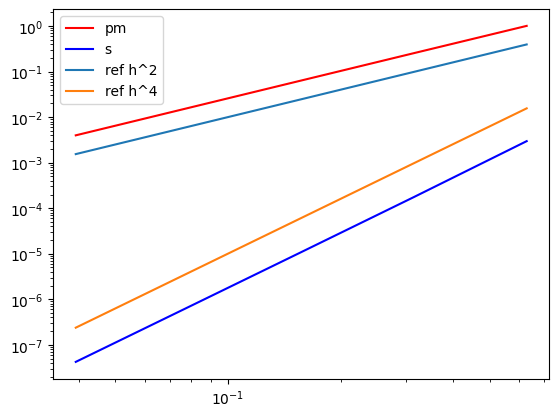

In [ ]:
fun = lambda x: np.sin(x)*np.power(x, 3)
I = -12*np.pi+2*np.pi**3
a = -np.pi
b = np.pi

N = np.array([10, 20, 40, 80, 160])
h = (b-a) / N

I_pm = []
I_s = []
for n in N:
    I_pm.append(pmedcomp(fun, a, b, n))
    I_s.append(simpcomp(fun, a, b, n))

I_pm = np.array(I_pm)
I_s = np.array(I_s)

plt.loglog(h, np.abs(I_pm-I), label="pm", color="red")
plt.loglog(h, np.abs(I_s-I), label="s", color="blue")

plt.loglog(h, np.square(h), label="ref h^2")
plt.loglog(h, 0.1*np.power(h, 4), label="ref h^4")

plt.legend()
plt.show()

Osserviamo che l'errore decade come predetto dalla teoria.

#### **(1c) (4 punti) [P]**  
Codificare una formula di quadratura interpolatoria composita a 10 intervalli Gaussiana a tre punti, che su ogni sotto-intervallo ha la forma
$$
    \sum_{i=0}^2 \alpha_i f(x_i)
$$
dove sull'intervallo di riferimento $(-1, 1)$ i nodi e i pesi sono definiti da $\hat{\alpha}_i = \{5/9, 8/9, 5/9\}$ e con nodi $\hat{x}_i = \{ -\sqrt{15}/5, 0, \sqrt{15}/5\}$. Calcolare quindi l'integrale numerico usando tale regola.

**Nota:** ricordarsi di mappare i nodi e i pesi dall'intervallo $(-1, 1)$ all'intervallo $(x_l, x_r)$ usando la seguente formula
$$
x_i = \frac{x_r-x_l}{2}  \hat{x}_i + \frac{x_r+x_l}{2}
\quad \text{e} \quad
\alpha_i = \frac{x_r-x_l}{2}\hat{\alpha}_i
$$


In [19]:
# traccia

alpha_ref = np.array([5/9, 8/9, 5/9])
x_ref = np.array([-np.sqrt(15)/5, 0 ,np.sqrt(15)/5])

I_g = 0
n = 10

x = np.linspace(a, b, n + 1) # griglia spaziale
x_l, x_r = x[:-1], x[1:] # liste dei nodi "sinistri" e "destri"

for i in np.arange(n): # ciclo su ogni sotto-intervallo
    x_i = (x_r[i]-x_l[i])/2*x_ref +(x_r[i]+x_l[i])/2
    alpha_i = (x_r[i]-x_l[i])/2*alpha_ref
    I_g += alpha_i @ f(x_i)        # equivalente a I_g = I_g + ...

print(I_g, I_g - I_ex)

24.313431599344774 -9.918177340750844e-06


##### **Soluzione.**

In [ ]:
alpha_ref = np.array([5, 8, 5]) / 9
x_ref = np.array([-1, 0, 1])*np.sqrt(15)/5

I_g = 0
n = 10

x = np.linspace(a, b, n + 1)
x_l, x_r = x[:-1], x[1:]

for i in np.arange(n):
    x_i = (x_r[i] - x_l[i]) / 2 * x_ref + (x_r[i] + x_l[i])/2
    alpha_i = alpha_ref * (x_r[i] - x_l[i]) / 2
    I_g += alpha_i @ fun(x_i)

print(I_g, I_g - I)

24.313431599344774 -9.918177340750844e-06


# **Esercizio 2 (10 punti)**


Si consideri la seguente funzione
\begin{gather*}
    f(x) = (e^xx -1)^2
\end{gather*}
dove $I=(-1,1)$.

#### **(2a) (1 punti) [P]**

Rappresentare graficamente $f$ e identificare, tramite il grafico, gli eventuali zeri nell'intervallo $I$ e la loro molteplicità.

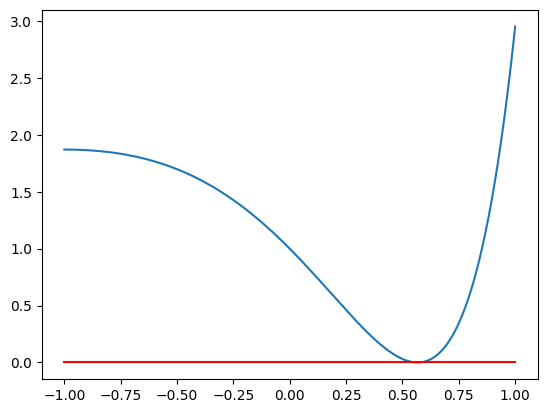

In [21]:
f=lambda x: (np.exp(x)*x -1)**2
a=-1
b=1
x_grid=np.linspace(a,b, 1000)
plt.figure()
plt.plot(x_grid, f(x_grid))
plt.plot(x_grid, np.zeros_like(x_grid), '-r')

In [22]:
#lo zero ha moltelicità almeno pari a 2

##### **Soluzione.**

Lo zero ha molteplicità almeno pari a 2.

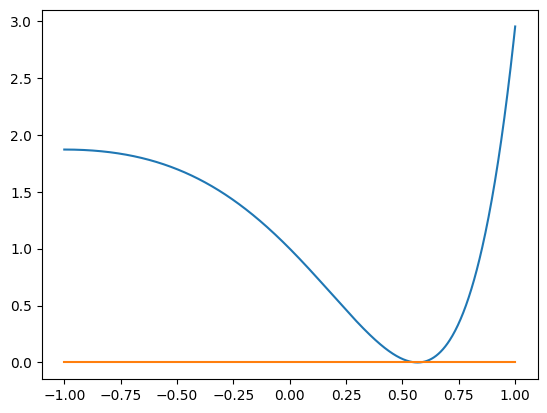

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = -1
b = 1
fun = lambda x: np.square(np.exp(x)*x-1)

x = np.linspace(a, b, 1000)
plt.plot(x, fun(x))
plt.plot(x, np.zeros_like(x))
plt.show()

#### **(2b) (4 punti) [T]**

Introdurre il metodo di Newton per la ricerca degli zeri di una funzione, dettagliando le sue proprietà.

In [23]:
#il metodo di Newton per la ricerca degli zeri di una funzione è un metodo iterativo basati sulla formula xk+1=xk-f(x)/f'(x)
#dimostro tale formula prendendo l'espansione in serie di Taylor della funzione f(x) centrata i nxk e arrestandomi al primo ordine:
#f(x)=f(xk)+f'(xk)*(x-xk) --> la valuto in xk+1 --> f(xk+1)=f(xk)+ f'(xk)*(xk+1-xk) e impongo che valga zero in xk+1:
#f(xk)+ f'(xk)*(xk+1-xk)=0 --> (xk+1-xk)= -f(xk)/f'(xk) --> xk+1=xk -f(xk)/f'(xk)

#il metodo di Newton è localmente convergente ma converge quadraticamente se la funzione f è di classe C1 nell'intervallo a,b e ha molteplicità
#algebrica pari a 1.
#se la molteplicità algebrica è maggiore di 1, la funzione perde la convergenza quadratica e tale convergenza ritorna lineare. 
#per recuperare tale convergenza quadratica bisogna usare il metodo di newton modificato

##### **Soluzione.**

Il metodo di Newton \`e un metodo per la ricerca degli
zeri di una funzione. Dato, all'iterazione $k$, un valore di tentativo per lo zero esatto $x^k$, la
retta tangente a $f$ in $x^k$ \`e data da
\begin{gather*}
    \frac{r(x) - f(x^k)}{x - x^k} = f^\prime(x^k) \quad \Rightarrow \quad
    r(x) = f(x^k) + f^\prime(x^k) ( x - x^k).
\end{gather*}
Notiamo che $r(x)+h.o.t=f(x)$ in un intorno di $x^k$.
Dato $x^k$, il punto $x^{k+1}$ \`e trovato come punto di intersezione della retta tangente
con l'asse $x$ ovvero lo zero della retta tangente $r$ approssimante $f$. Abbiamo che
\begin{gather*}
    r(x^{k+1}) = f(x^k) + f^\prime (x^k) (x^{k+1} - x^k) = 0
    \quad \Rightarrow \quad x^{k+1} = x^k - \frac{f(x^k)}{f^\prime(x^k)}
\end{gather*}
Possiamo quindi generare una sequenza $\{x^k\}$ e sperare che converga verso lo
zero di $f$ sfruttando non solo il valore della funzione, ma anche le informazioni sulla sua
derivata.

Il metodo di Newton \`e solamente
localmente convergente, ma se converge lo fa quadraticamente.

#### **(2c) (3 punti) [P]**

Utilizzando come valore iniziale $x_0 = 0$, calcolare lo zero fornito dal metodo di Newton dettagliando il numero di iterazioni richieste. Rappresentare graficamente l'andamento dell'errore e confrontarlo con quanto predetto dalla teoria, commentare i risultati ottenuti.

La soluzione esatta si può ottenere tramite il seguente codice

In [24]:
from scipy.special import lambertw
from utilis_ricerca_zeri import newton

alpha_ex = lambertw(1).real
print(alpha_ex)

0.5671432904097838


0.5671423741110962
17


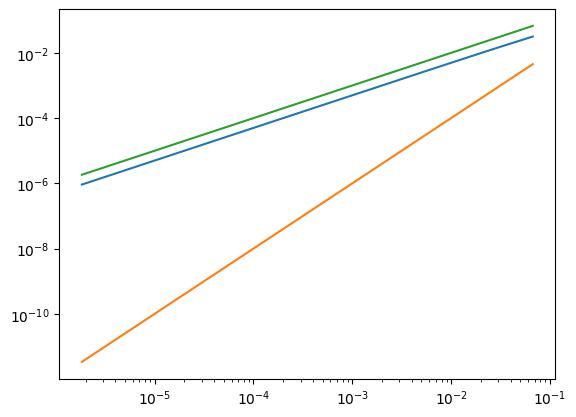

In [30]:
x0=0
df=lambda x: 2*(np.exp(x)*x-1)*(np.exp(x)*x+np.exp(x))

x_newton=newton(f,df,x0)
print(x_newton[-1])
print(len(x_newton))
err=np.abs(x_newton - alpha_ex)
err_n=np.array(err[:-1])
err_n1=np.array(err[1:])
plt.figure()
plt.loglog(err_n, err_n1)
plt.loglog(err_n, err_n**2)
plt.loglog(err_n, err_n)

##### **Soluzione.**

Consideriamo il seguente condice.

0.5671423741110962 17 -9.16298687592132e-07


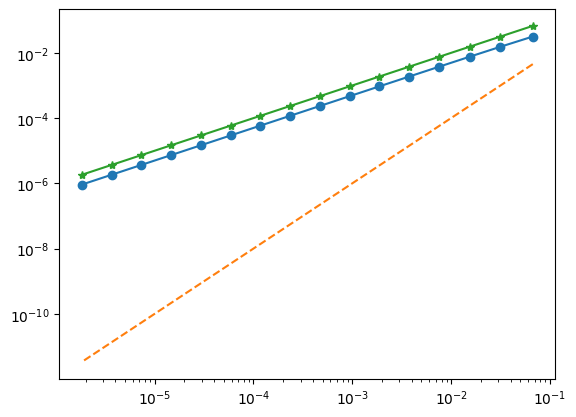

In [ ]:
d_fun = lambda x: 2*(x*np.exp(x) - 1)*(x + 1)*np.exp(x)

x_0 = 0
x_val = newton(fun, d_fun, x_0)
print(x_val[-1], x_val.size, x_val[-1] - alpha_ex)

err = np.abs(x_val - alpha_ex)
e_n = np.array(err[:-1])
e_n1 = np.array(err[1:])
# Plot log(e_n) vs. log(e_{n+1})
plt.loglog(e_n, e_n1, "o-")
plt.plot(e_n, e_n**2, "--")
plt.plot(e_n, e_n, "-*")

plt.show()

Il metodo di Newton dovrebbe convergere quadratiamente, ma in questo caso lo fa solamente linearmente. Ciò è dovuto al fatto che lo zero NON è semplice.

#### **(2d) (2 punti) [P+T]**

Proporre una soluzione per poter ottenere nuovamente convergenza quadratica del metodo di Newton, verificandola in python.

In [31]:
#per ottenere la convergenza quadratica dobbiamo usare il metodo di newton modificato

0.567143290409784
6


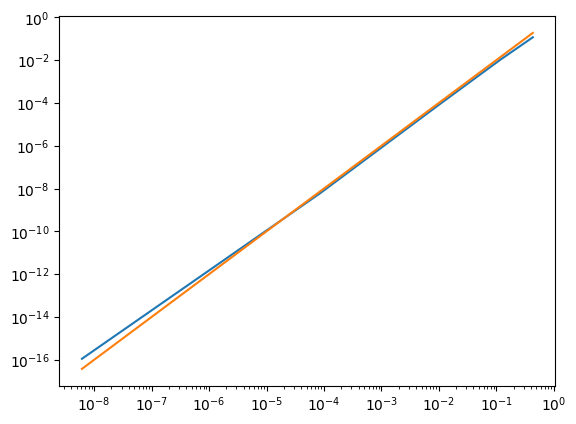

In [34]:
x_new_mod=newton(f, df, x0, m=2)
print(x_new_mod[-1])
print(len(x_new_mod))
err_mod=np.abs(x_new_mod-alpha_ex)
err_mod_n=err_mod[:-1]
err_mod_n1=err_mod[1:]

plt.loglog(err_mod_n, err_mod_n1)
plt.loglog(err_mod_n, err_mod_n**2)

##### **Soluzione.**

Possiamo considerare la versione modificata del metodo di Newton, consideriamo il seguente codice.

0.567143290409784 6 1.1102230246251565e-16 0.5671432904097838


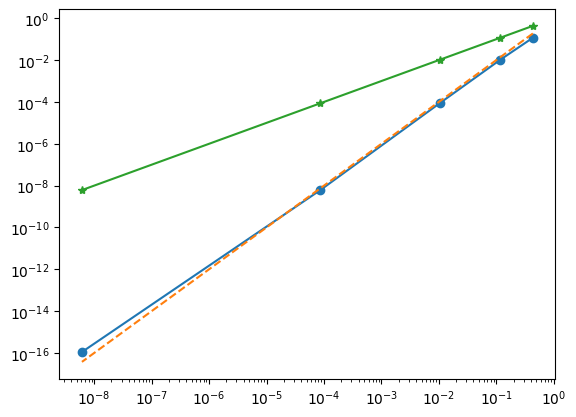

In [ ]:
x_val = newton(fun, d_fun, x_0, m=2)
print(x_val[-1], x_val.size, x_val[-1]-alpha_ex, alpha_ex)

err = np.abs(x_val - alpha_ex)
e_n = np.array(err[:-1])
e_n1 = np.array(err[1:])

# Plot log(e_n) vs. log(e_{n+1})
plt.loglog(e_n, e_n1, "o-")
plt.plot(e_n, e_n**2, "--")
plt.plot(e_n, e_n, "-*")

plt.show()

Notiamo che in questo caso la convergenza è quadratica.

# **Esercizio 3 (10 punti)**

Si consideri il seguente problema differenziale

\begin{gather*}
\begin{cases}
-u^{\prime\prime}(x) + u(x) = f(x), \quad x \in (0, 1)\\
u(0) = 0 \\
u(1) = 0
\end{cases}
\end{gather*}

#### **(3a) (1 punti) [T]**

Calcolare la forzante $f(x)$ in modo che $u(x) = \sin(\pi x)$ sia la soluzione esatta del problema. Verificare inoltre che questa soluzione soddisfi le condizioni al contorno.

##### **Soluzione.**

Per ricavare la forzante sostituiamo $u(x)$ nell'equazione, dopo aver calcolato $u^{\prime\prime}(x) = \pi^2\sin(\pi x)$:

$$
-\pi^2\sin(\pi x) + \sin(\pi x) = f(x).
$$
Inoltre, osserviamo che $u(0)=\sin(0)=0$ e $u(1) = \sin(\pi)=0$, quindi la soluzione rispetta le condizioni al contorno.

#### **(3b) (3 punti) [T]**

Scrivere la formulazione debole del problema in esame e illustrare la sua soluzione numerica con il metodo degli elementi finiti, senza ricavare esplicitamente l'espressione della matrice e del termine noto.

##### **Soluzione.**

Per presentare la formulazione debole del problema, introduciamo anzitutto lo spazio funzionale $V$
\begin{gather*}
V = \{v \in H^1(0, 1): v(0) = 0,\,  v(1) = 0\}
\end{gather*}
procediamo quindi alla formulazione debole del problema
\begin{gather*}
\int_0^{1}-u^{\prime\prime}v + \int_0^{1} u v = \int_0^1 f v \\
\int_0^{1} u^\prime v^\prime - [u^{\prime} v]_0^{1} + \int_0^{1}  u v = \int_0^1 f v.
\end{gather*}
Il termine di bordo si annulla in $0$ e $1$ dato che $v\in V$.
Introduciamo quindi la forma bilineare $a$, la forma bilineare $c$ e il funzionale $F$ seguenti
\begin{gather*}
a(u, v) =  \int_0^{1} u^\prime v^\prime\qquad c(u,v) = \int_0^{1} u v \qquad F(v) = \int_0^{1} f v
\end{gather*}
e quindi il problema debole risulta: trovare $u \in V$ tale che
\begin{gather*}
a(u, v) + c(u,v) = F(v)\qquad \forall v \in V
\end{gather*}

Il metodo di Galerkin costruisce un sottospazio $V_h$ finito dimensionale di $V$
tale per cui per $h\rightarrow 0$ allora $V_h \rightarrow V$, dove appunto $h$
è il passo di griglia o comunque un parametro legato alla discretizzazione.

Scelto quindi uno spazio $V_h$, introduciamo ora la formulazione di Galerkin del problema visto
precedentemente, che consiste nel trovare $u_h \in V_h$ tale che
\begin{gather*}%\label{eq:gal}
    a(u_h, v_h) + c(u_h,v_h) = F(v_h) \quad \forall v_h \in V_h
\end{gather*}
Essendo $v_h$ e $u_h$ elementi di $V_h$ allora
possiamo espanderli sulla base introdotta e scriverli come
\begin{gather*}
    v_h (x) = \sum_{i=1}^{N_h} \alpha_i \phi_i(x)
    \quad \text{e} \quad
    u_h (x) = \sum_{j=1}^{N_h} u_j \phi_j (x),
\end{gather*}
dove $\alpha_i \in \mathbb{R}$ e $u_j \in \mathbb{R}$ per ogni $i$ e $j=1,
\ldots, N_h$.
Sostituendo l'espressione di $v_h$ nell'equazione vista precedentemente e
sfruttando la linearità nel secondo argomento di $a$ e $c$ e la linearità di $F$
otteniamo
\begin{gather*}
    a(u_h, v_h) + c(u_h,v_h) = F(v_h)
    \quad\rightarrow \quad
    a\left(u_h, \sum_{i=1}^{N_h} \alpha_i \phi_i\right)+c\left(u_h, \sum_{i=1}^{N_h} \alpha_i \phi_i\right) =
    F\left(\sum_{i=1}^{N_h} \alpha_i \phi_i\right)\\
    \sum_{i=1}^{N_h} \alpha_i a\left(u_h, \phi_i\right)+\sum_{i=1}^{N_h} \alpha_i c\left(u_h, \phi_i\right) =
    \sum_{i=1}^{N_h} \alpha_i F\left(\phi_i\right),
\end{gather*}
ma, dato che tale relazione deve valere per tutti i $v_h \in V_h$, questo implica che deve valere
\begin{gather*}
    a\left(u_h, \phi_i\right) +  c\left(u_h, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h.
\end{gather*}

Il sistema è ora formato da $N_h$ equazioni e non più un numero
infinito come visto precedentemente. Nel caso degli elementi finiti lineari con condizioni al bordo di Dirichlet abbiamo un numero di equazioni pari al numero di nodi interni della griglia. Inoltre, come detto, anche la soluzione discreta $u_h$ può essere scritta data la base
$\{\phi_i\}$ nel seguente modo
\begin{gather*}
    u_h(x) = \sum_{j=1}^{N_h} u_j \phi_j(x)
\end{gather*}
dove $u_j$ sono ora coefficienti da determinare. A questo punto infatti
determinare la soluzione numerica $u_h$ equivale a
determinare i valori $\{u_j\}$, detti anche gradi di libertà, dato che le $\phi_j$ sono note (saranno definite più precisamente in seguito)
\begin{gather*}
    u_h(x) = \sum_{i=1}^{N_h} u_j \phi_j(x) \quad \xrightarrow{\text{è definita dal vettore}} \quad {u} = [u_1, \ldots, u_{N_h}]^\top.
\end{gather*}
Sostituiamo nell'espressione precedente l'espansione di $u_h$ sulla base di
$V_h$ per ottenere
\begin{gather*}
    a\left(u_h, \phi_i\right)+c\left(u_h, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h
    \quad \rightarrow \quad
    a\left(\sum_{i=1}^{N_h} u_j \phi_j, \phi_i\right) + c\left(\sum_{i=1}^{N_h} u_j \phi_j, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h
\end{gather*}
e dalla bi-linearità della forma $a$ e $c$ otteniamo che
\begin{gather*}
    \sum_{i=1}^{N_h} u_j a\left(\phi_j, \phi_i\right)+\sum_{i=1}^{N_h} u_j c\left(\phi_j, \phi_i\right) =
    F\left(\phi_i\right)
    \quad \forall i=1,\ldots,N_h.
\end{gather*}
Il problema discreto precedente viene scritto ora come la risoluzione di un
problema lineare, detto problema algebrico equivalente, ovvero trovare ${u}$ tale che
\begin{gather*}
    (A+C) {u} = {f}.
\end{gather*}

#### **(3c) (2 punti) [P]**

Completare la function `elliptic_problem` fornita di seguito nei punti indicati da ''TODO'', per ottenere una function che risolve il problema fornito ricevendo in input la dimensione degli elementi della griglia.

##### **Soluzione.**

Consideriamo il seguente codice

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sps
from fem import *

In [ ]:
domain = Line(0, 1)

In [ ]:
def elliptic_problem(h):

    mesh = generate_mesh(domain, stepsize=h)
    Vh = FEspace(mesh, 1)

    f = lambda x: (1+np.pi**2)*np.sin(np.pi*x)
    fh = interpolate(f, Vh)

    def l(v):
        return  fh*v*dx

    def a(u, v):
        return deriv(u)*deriv(v)*dx

    def c(u, v):
        return 1*u*v*dx

    uh = trial_function(Vh)
    vh = test_function(Vh)

    # Assembla la matrice e il termine noto
    A = assemble(a(uh, vh))
    C = assemble(c(uh, vh))
    F = assemble(l(vh))

    # Aggiustamento delle condizioni al bordo
    from fem import DirichletBC

    def isLeftNode(x):
      return x < 1e-12

    def isRightNode(x):
      return x > 1 - 1e-12

    dbc1 = DirichletBC(isLeftNode,  0.0)
    dbc2 = DirichletBC(isRightNode, 0.0)

    from fem import applyBCs
    A = applyBCs(A, Vh, dbc1, dbc2)
    C = applyBCs(C, Vh, dbc1, dbc2)
    F = applyBCs(F, Vh, dbc1, dbc2)


    # Risolvi il sistema lineare e reinterpreta la soluzione come funzione
    u = sps.linalg.spsolve(A+C, F)
    uh = dof2fun(u, Vh)
    return uh



#### **(3d) (2 punti) [P]**

Applicare la function `elliptic_problem` con $h=0.1$. Rappresentare la soluzione numerica ottenuta e confrontarla con quella esatta.

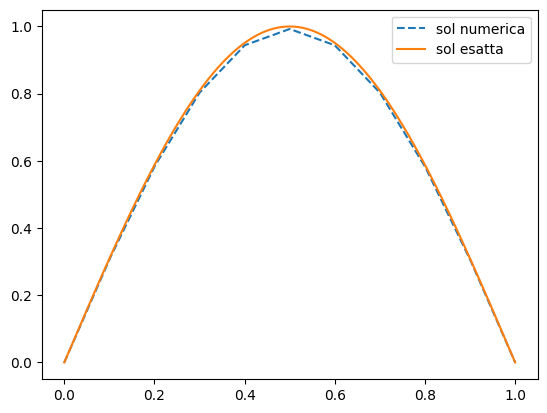

In [18]:
from fem_utils import *
#costruisco la griglia
a, b= 0,1
h=0.1
Nele=int((b-a)/h)
grid=Grid(a,b, Nele)
grid.compute_geometry()

#f e uex
u_ex=lambda x: np.sin(np.pi*x)
f= lambda x: np.sin(np.pi*x)*(np.pi**2+1)

#creo matrice diffusione e reazione
A_diff=diffusion(grid)
A_reac=mass(grid)
A= A_diff+A_reac

#vettore termine noto
f_dofs=fun2dof(grid,f)
M=A_reac
F=M @ f_dofs

#condizioni di dirichlet
dirichlet_nodes=[0,-1]
dirichlet_values=[0,0]
bc_values=np.zeros(Nele+1)
bc_values[dirichlet_nodes]=dirichlet_values

#matrice di restrizione 
keep_dof=np.ones(Nele+1, dtype=bool)
keep_dof[dirichlet_nodes]=False
R=create_restriction(keep_dof)

#prendo gdl interni
A_0=R @ A @ R.T
F_0 = R @ (F - A @ bc_values)

#risolvo sistema per nodi interni
u_0=np.linalg.solve(A_0, F_0)

#aggiungo bc + valuto interpolante
u=R.T @ u_0 + bc_values
uh= lambda x: np.interp(x,grid.nodes,u)
#grafico 
xx=np.linspace(0,1, 1000)
plt.figure()
plt.plot(xx, uh(xx),'--',label='sol numerica')
#plt.plot(grid.nodes, u,'--',label='sol numerica')
plt.plot(xx, u_ex(xx), label='sol esatta')
plt.legend()
plt.show()

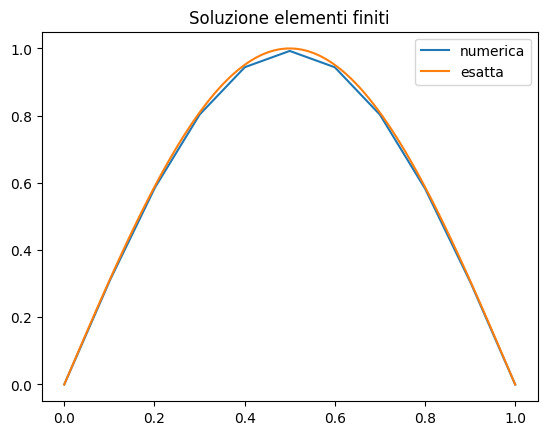

In [ ]:
uh = elliptic_problem(0.1)
# Rappresentazione grafica della soluzione
plot(uh, title = "Soluzione elementi finiti",label='numerica')

xplot = np.linspace(0,1,100)
uex = lambda x: np.sin(np.pi*x)
plt.plot(xplot, uex(xplot),label='esatta')
plt.legend()

#### **(3e) (2 punti) [P]**

Ripetere il calcolo della soluzione numerica per $h=[0.05, 0.25, 0.01]$ e calcolare i corrispondenti errori utilizzando la function `L2error`. Rappresentare gli errori in scala logaritmica in funzione di $h$: cosa si osserva? Commentare il risultato alla luce della teoria.

In [19]:
err=[]
h=np.array([0.05, 0.025, 0.01])

def elliptic_problem(h):
   a, b= 0,1
   Nele=int((b-a)/h)
   grid=Grid(a,b, Nele)
   grid.compute_geometry()

   #f e uex
   u_ex=lambda x: np.sin(np.pi*x)
   f = lambda x: np.sin(np.pi*x)*(np.pi**2+1)

   #creo matrice diffusione e reazione
   A_diff=diffusion(grid)
   A_reac=mass(grid)
   A= A_diff+A_reac

   #vettore termine noto
   f_dofs=fun2dof(grid,f)
   M=A_reac
   F=M @ f_dofs

   #condizioni di dirichlet
   dirichlet_nodes=[0,-1]
   dirichlet_values=[0,0]
   bc_values=np.zeros(Nele+1)
   bc_values[dirichlet_nodes]=dirichlet_values

   #matrice di restrizione 
   keep_dof=np.ones(Nele+1, dtype=bool)
   keep_dof[dirichlet_nodes]=False
   R=create_restriction(keep_dof)

   #prendo gdl interni
   A_0=R @ A @ R.T
   F_0 = R @ (F - A @ bc_values) 

   #risolvo sistema per nodi interni
   u_0=np.linalg.solve(A_0, F_0)

   #aggiungo bc + valuto interpolante
   u=R.T @ u_0 + bc_values
   uh= lambda x: np.interp(x,grid.nodes,u)
   return uh

for i in h:
   uh=elliptic_problem(h)
   err.append(L2error(u_ex, uh, domain))


TypeError: only 0-dimensional arrays can be converted to Python scalars

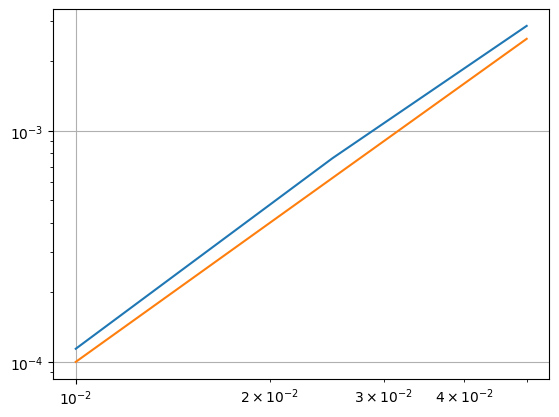

In [ ]:
err = []
H = np.array([0.05, 0.025, 0.01])
for h in H:
    uh=elliptic_problem(h)
    err.append(L2error(uex,uh,domain))

plt.loglog(H,err)
plt.loglog(H,H**2)
plt.grid()

Osserviamo che l'errore in norma $L^2$ converge quadraticamente con $h$, come previsto dalla teoria.